## Import de librerías

In [1]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit


## Import de dataset

In [2]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/04-null-processed/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)


1 files merged
(2933082, 24)


## Análisis de outliers

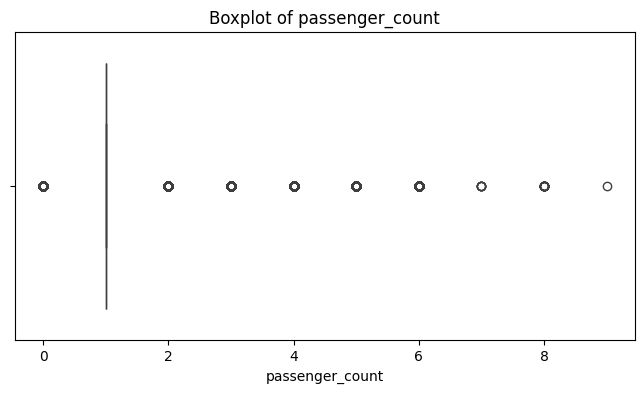

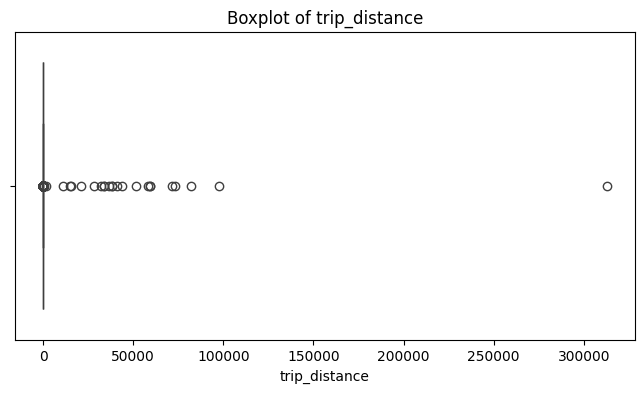

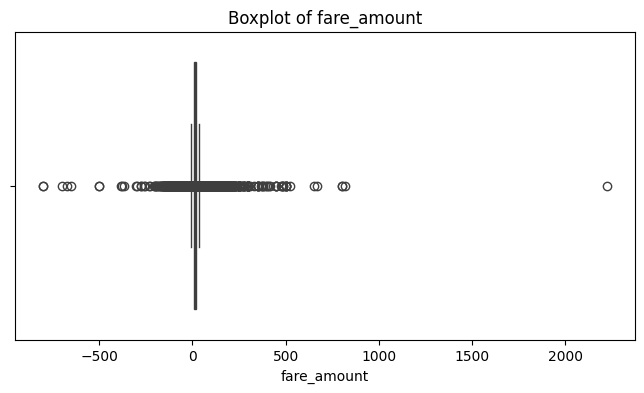

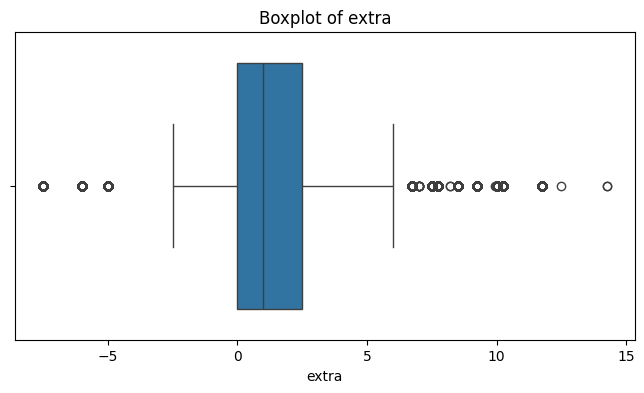

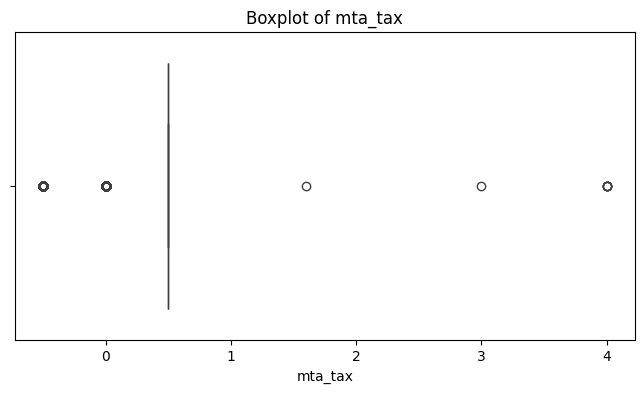

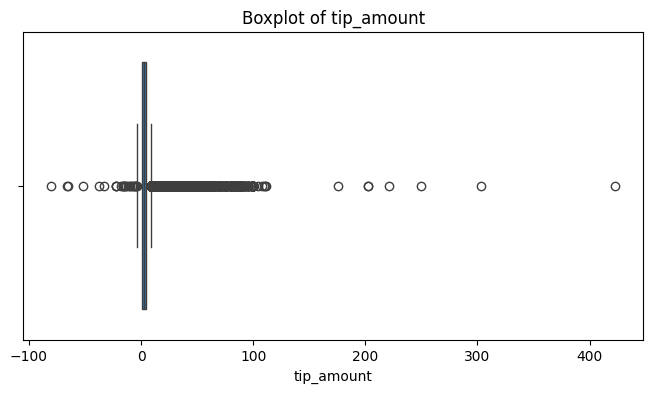

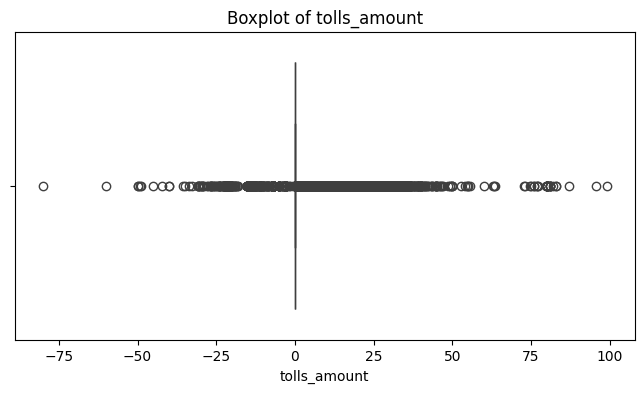

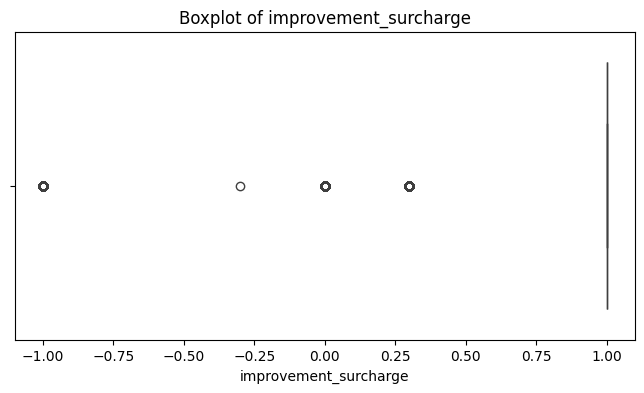

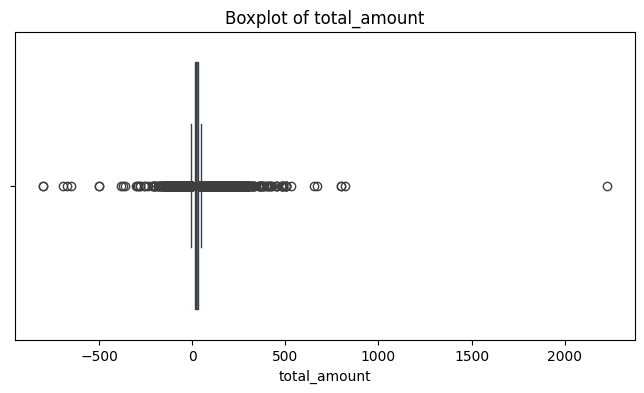

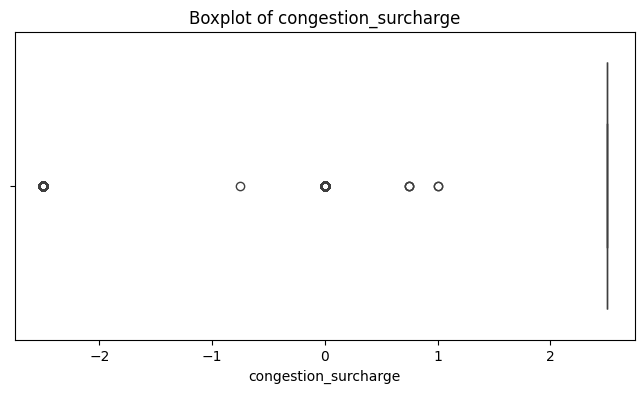

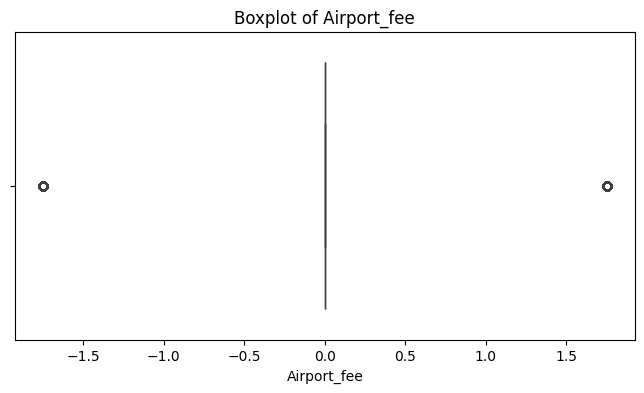

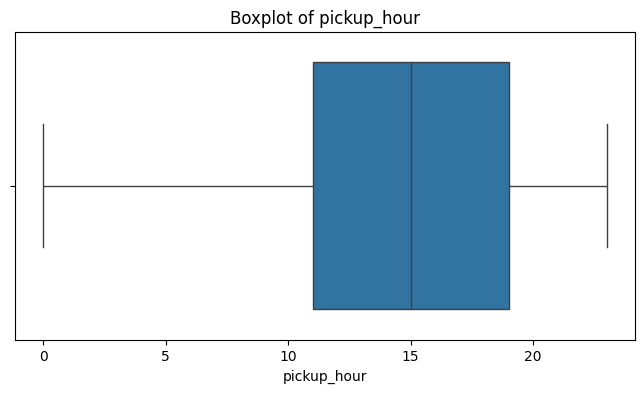

In [3]:
# boxplot de variables numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Ajuste de negativos

In [4]:
# ninguna de las columnas numéricas debería tener valores negativos, pasamos a valor absoluto
for col in num_cols:
    df[col] = df[col].abs()

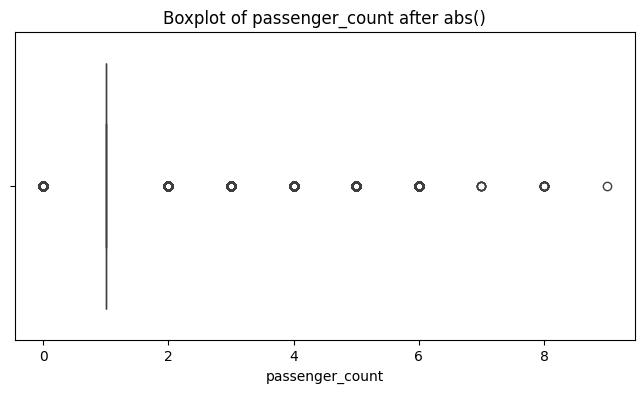

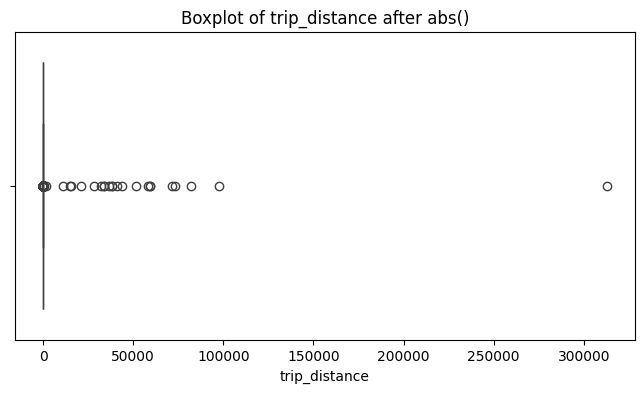

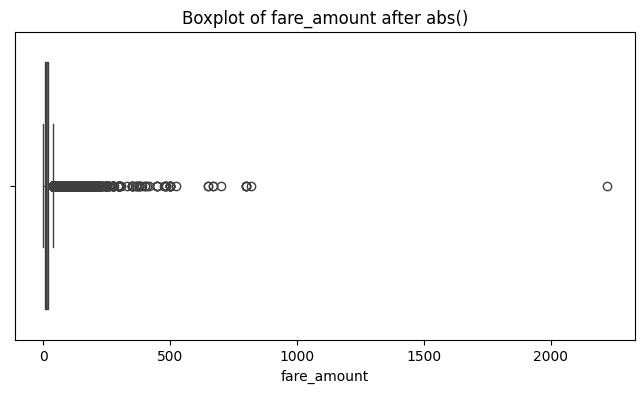

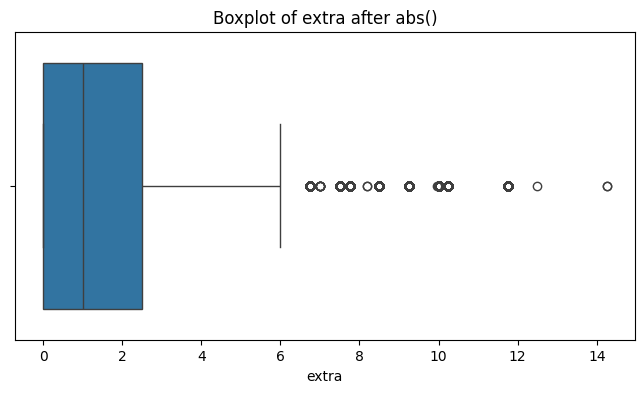

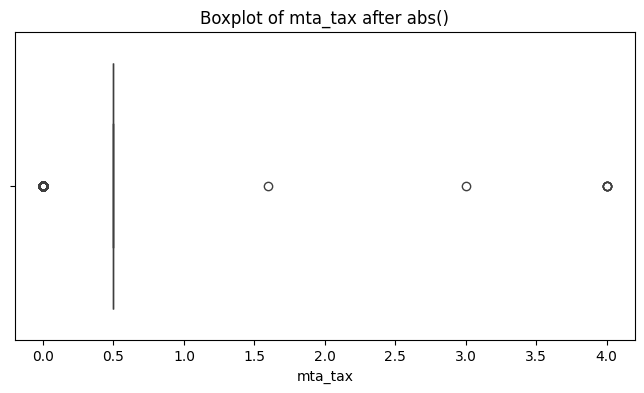

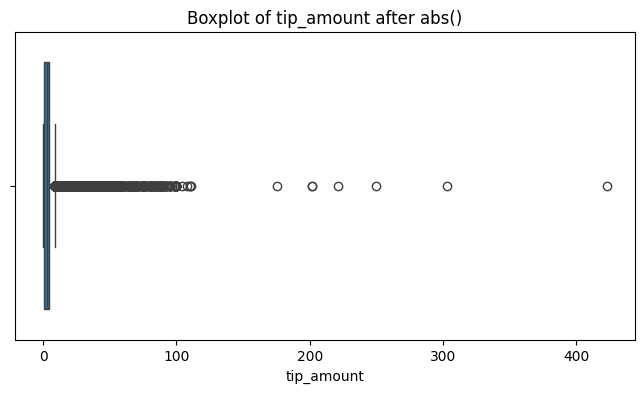

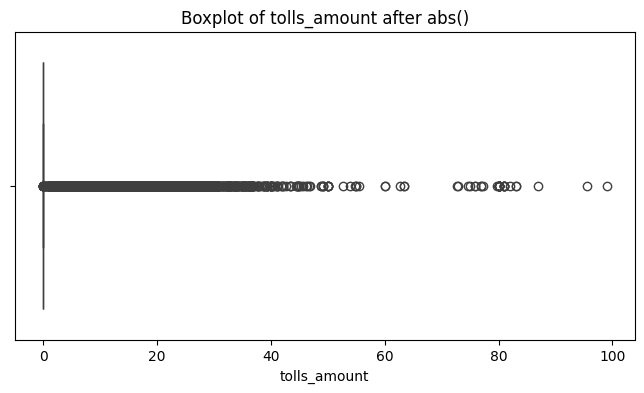

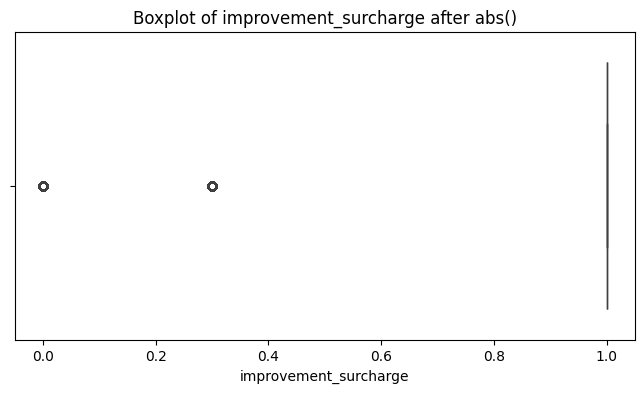

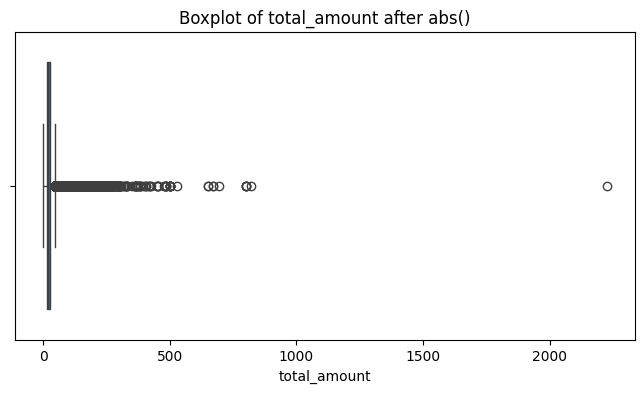

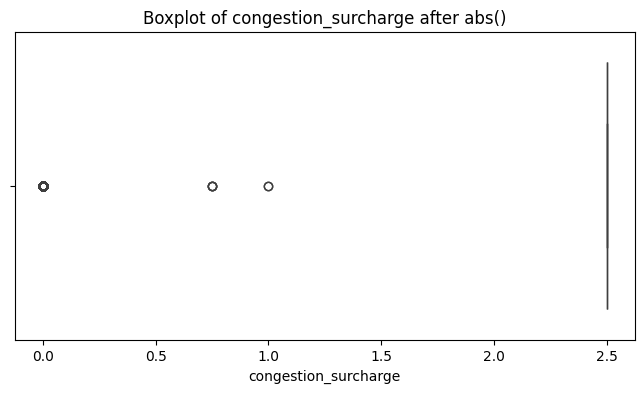

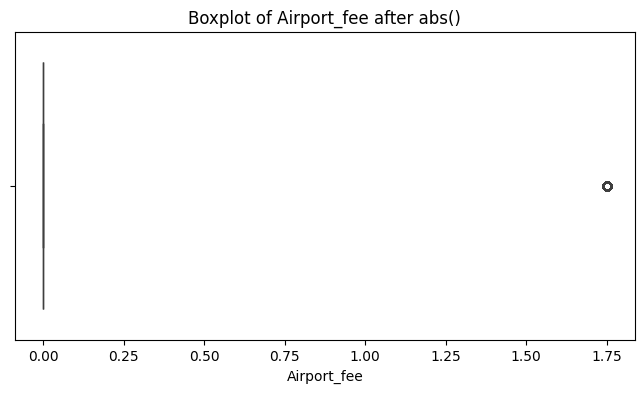

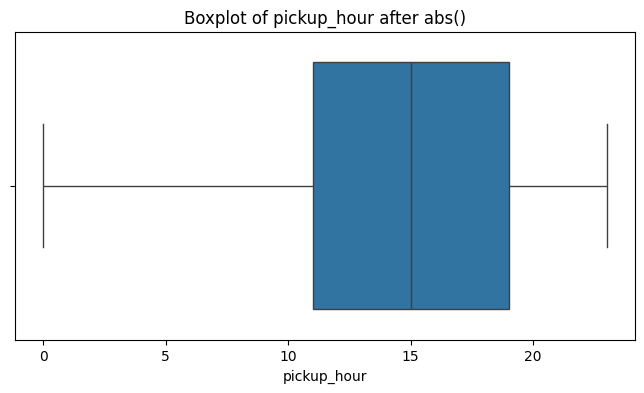

In [5]:
# boxplot de variables numéricas después de pasar a valor absoluto
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} after abs()')
    plt.show()

## Passenger count outliers treatment

In [6]:
# cualquier valor por encima de 5 para passenger_count lo tomamos como outlier. 
df = df[df['passenger_count'] <= 5]

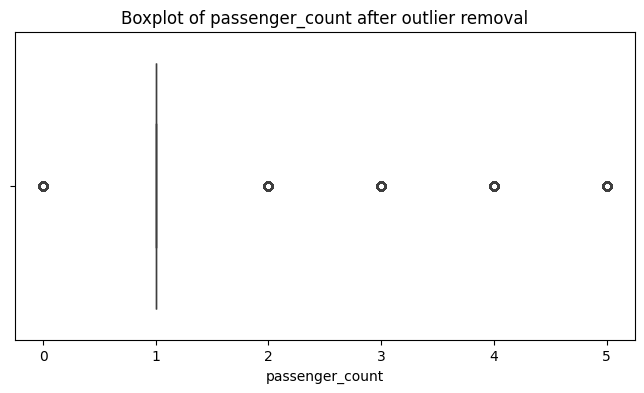

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['passenger_count'])
plt.title(f'Boxplot of passenger_count after outlier removal')
plt.show()

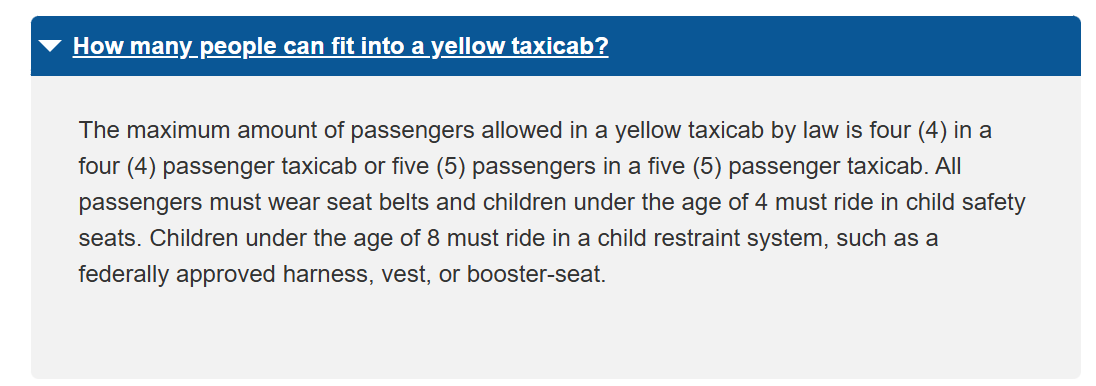
[fuente](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page)

In [11]:
# cuantos valores con 5 pasajeros? 
df['passenger_count'].value_counts().sort_index()

passenger_count
0      30306
1    2306226
2     400253
3      90012
4      51038
5      33104
Name: count, dtype: Int64